# Customer Churn Prediction with XGBoost

## Business Problem
A telecommunications company wants to predict which customers are likely to leave their service (churn). 
By identifying at-risk customers early, the company can take proactive measures to retain them, 
such as offering discounts, improved service, or personalized outreach.

## Why XGBoost?
XGBoost is particularly well-suited for this problem because:
1. **Handles mixed data types:** Can work with numerical, categorical, and missing data
2. **Feature importance:** Provides insights into what factors drive churn
3. **Handles class imbalance:** Our dataset has imbalanced classes (more non-churners)
4. **High performance:** Fast and accurate for tabular data like this

## Dataset Overview
The dataset contains 7043 customer records with 21 features:

### Key Features:
- **Demographics:** gender, SeniorCitizen, Partner, Dependents
- **Services:** PhoneService, MultipleLines, InternetService, OnlineSecurity, etc.
- **Account info:** tenure, Contract, PaperlessBilling, PaymentMethod
- **Charges:** MonthlyCharges, TotalCharges
- **Target:** Churn (Yes/No)

### Data Types:
- Numerical: tenure, MonthlyCharges, TotalCharges
- Categorical: All other features
- Binary target: Churn (Yes/No)

## Our Task
1. **Preprocess** the data (handle missing values, encode categorical variables)
2. **Build an XGBoost model** to predict customer churn
3. **Optimize** the model for business impact (prioritize catching churners)
4. **Interpret** results to provide actionable insights to the business team

In [1]:
# Import the data from Kaggle
import kagglehub
import os
os.environ['KAGGLEHUB_CACHE'] = './Data'
# Download the latest version
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

In [2]:
# Libs 
import pandas as pd 
pd.set_option('display.width', 200)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
df = pd.read_excel(path+'/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
# Check the data type
print(f'type of columns:\n{df.dtypes}')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Check the missing values
print(f'The missing values: \n{df.isna().sum()}')

type of columns:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object
The missing 

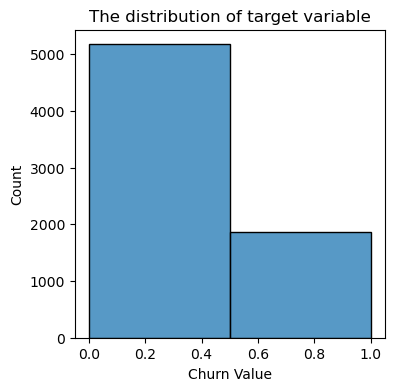


****************************************************************************************************
The model should be better majority class ratio: 0.7346301292063041
****************************************************************************************************



In [4]:
# Check the target column
y = df['Churn Value']
fig, ax = plt.subplots(figsize=(4,4))
sns.histplot(y, bins=2, lw=1)
ax.set(title = 'The distribution of target variable')
plt.show()

base_chance_level = 1 - sum(df['Churn Value'] == 1)/df.shape[0]

print(f'\n{'*'*100}\nThe model should be better majority class ratio: {base_chance_level}\n{'*'*100}\n')

In [5]:
# Find numeric columns
num_col = df.select_dtypes(include=np.number).drop('Churn Value', axis=1).columns .tolist()

# Check the numeric columns information
print(df[num_col].describe().T)

# Eliminate Count column as it has zero std
# Churn Value is the target column 
# Churn Score has too much info about the Churn Value
num_col = [col for col in num_col if col not in['Churn Value', 'Count', 'Churn Score']]

                  count          mean          std           min           25%           50%           75%           max
Count            7043.0      1.000000     0.000000      1.000000      1.000000      1.000000      1.000000      1.000000
Zip Code         7043.0  93521.964646  1865.794555  90001.000000  92102.000000  93552.000000  95351.000000  96161.000000
Latitude         7043.0     36.282441     2.455723     32.555828     34.030915     36.391777     38.224869     41.962127
Longitude        7043.0   -119.798880     2.157889   -124.301372   -121.815412   -119.730885   -118.043237   -114.192901
Tenure Months    7043.0     32.371149    24.559481      0.000000      9.000000     29.000000     55.000000     72.000000
Monthly Charges  7043.0     64.761692    30.090047     18.250000     35.500000     70.350000     89.850000    118.750000
Total Charges    7032.0   2283.300441  2266.771362     18.800000    401.450000   1397.475000   3794.737500   8684.800000
Churn Score      7043.0     58.6

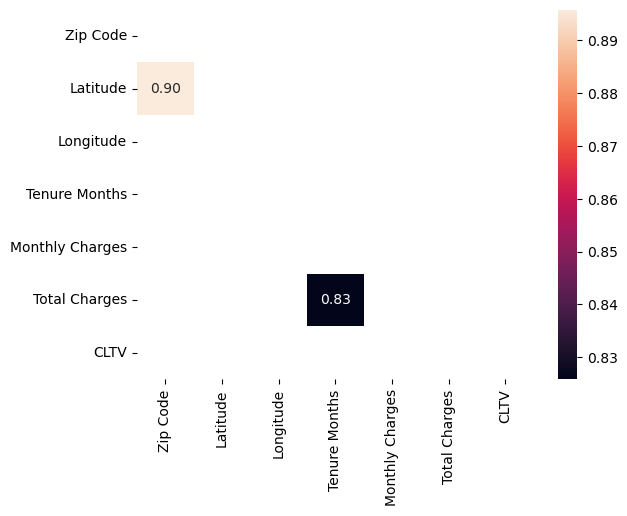

In [6]:
# Check the correlation between numerical features
corr_mtx = df[num_col].corr()

# Create a mask for lower triangular and cor > 0.8
mask = np.triu(np.ones_like(df[num_col].corr(), dtype=bool))

df_num_corr = corr_mtx[corr_mtx.mask(mask) > 0.8]

# Visualize the corr matrix
sns.heatmap(df_num_corr, annot=True, fmt = '.2f')
plt.show()

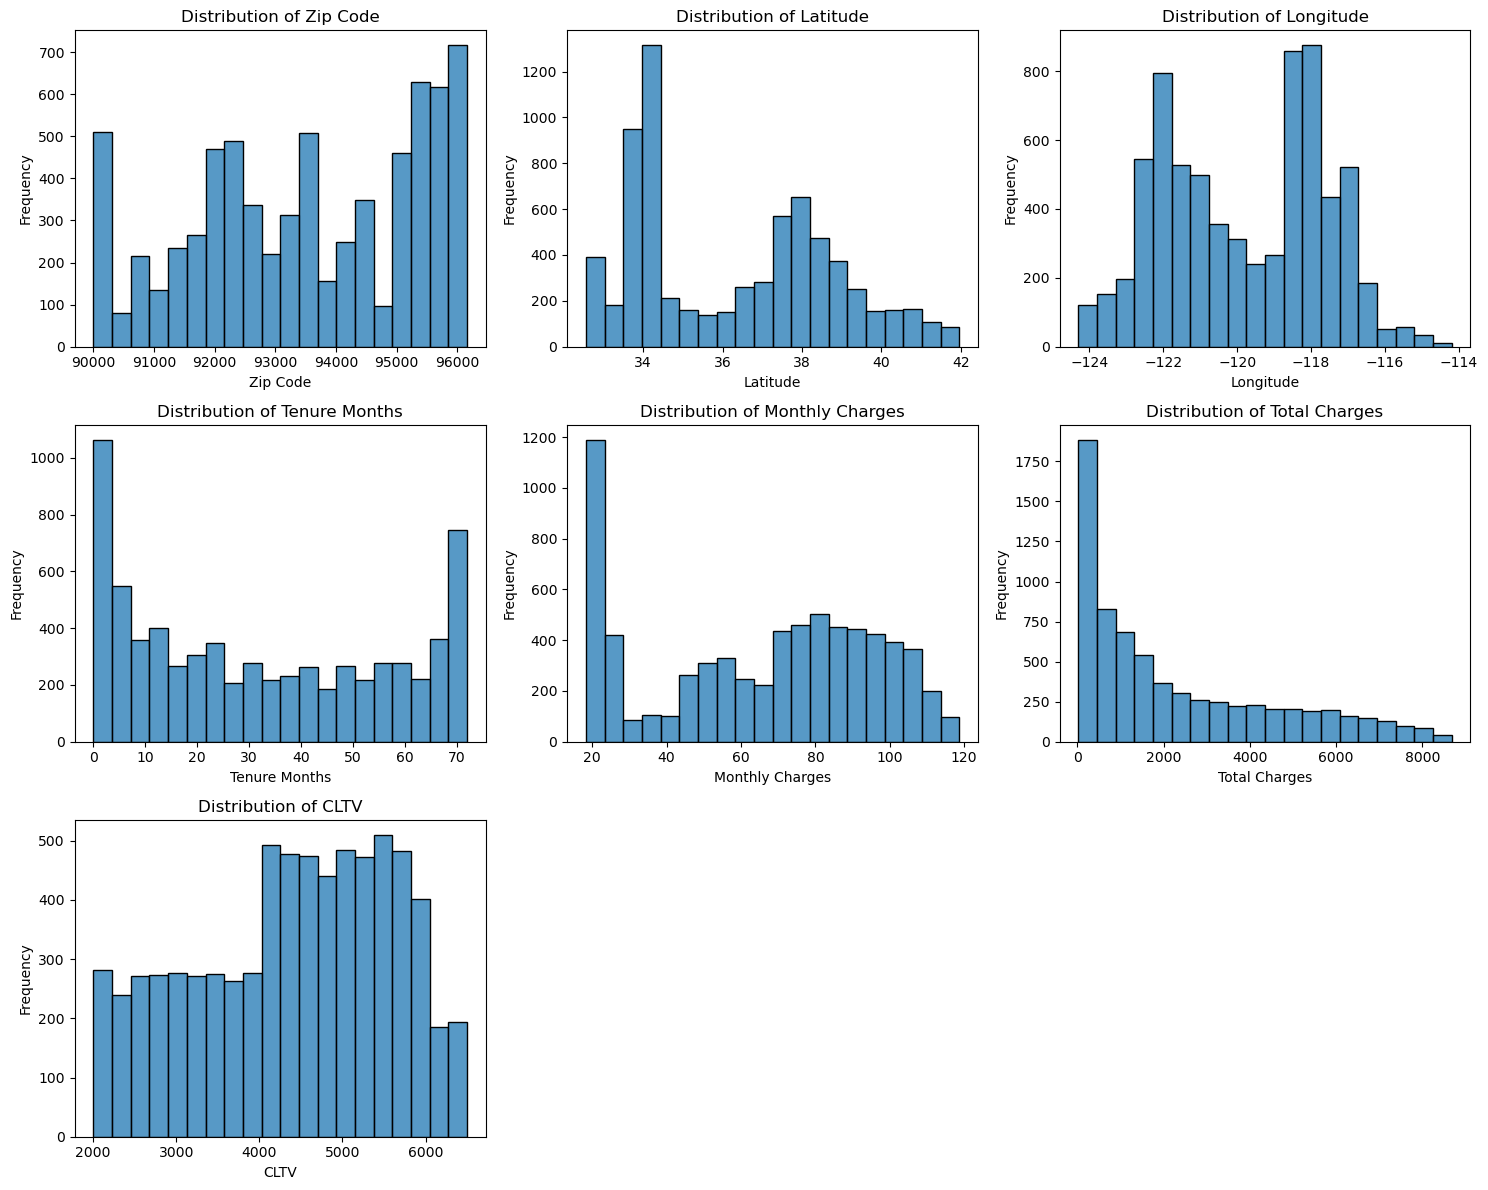

In [7]:
# Visualize the distributions of num columns
col_num = 3
row_num = len(num_col)//col_num + 1

fig, axes = plt.subplots(row_num, col_num, figsize=(15, row_num * 4))

# Flatten axes array for easier iteration
axes = axes.ravel()

for idx, col in enumerate(num_col):
    # Add plot for each numeric column
    sns.histplot(df[col], bins=20, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide any unused subplots
for idx in range(len(num_col), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# Find categorical columns
cat_col = df.select_dtypes('object').columns.tolist()

# Check the cat columns information
print(df[cat_col].describe().T)

# Eliminate ID, Country, Lat Long, Churn Reason and State columns
# ID is unique per row, therefore not useful for the model
# Country and State have only 1 unique value
# Lat Long is presented as latitude and longitude in numerical features 
# Churn Reason separates Churned and non_Churned perfectly
# Churn label is obj form of Churn value
cat_col = [col for col in cat_col if col not in ['CustomerID', 'Country', 'State', 'Lat Long', 'Churn Reason', 'Churn Label']]

                  count unique                         top  freq
CustomerID         7043   7043                  3668-QPYBK     1
Country            7043      1               United States  7043
State              7043      1                  California  7043
City               7043   1129                 Los Angeles   305
Lat Long           7043   1652      33.964131, -118.272783     5
Gender             7043      2                        Male  3555
Senior Citizen     7043      2                          No  5901
Partner            7043      2                          No  3641
Dependents         7043      2                          No  5416
Phone Service      7043      2                         Yes  6361
Multiple Lines     7043      3                          No  3390
Internet Service   7043      3                 Fiber optic  3096
Online Security    7043      3                          No  3498
Online Backup      7043      3                          No  3088
Device Protection  7043  

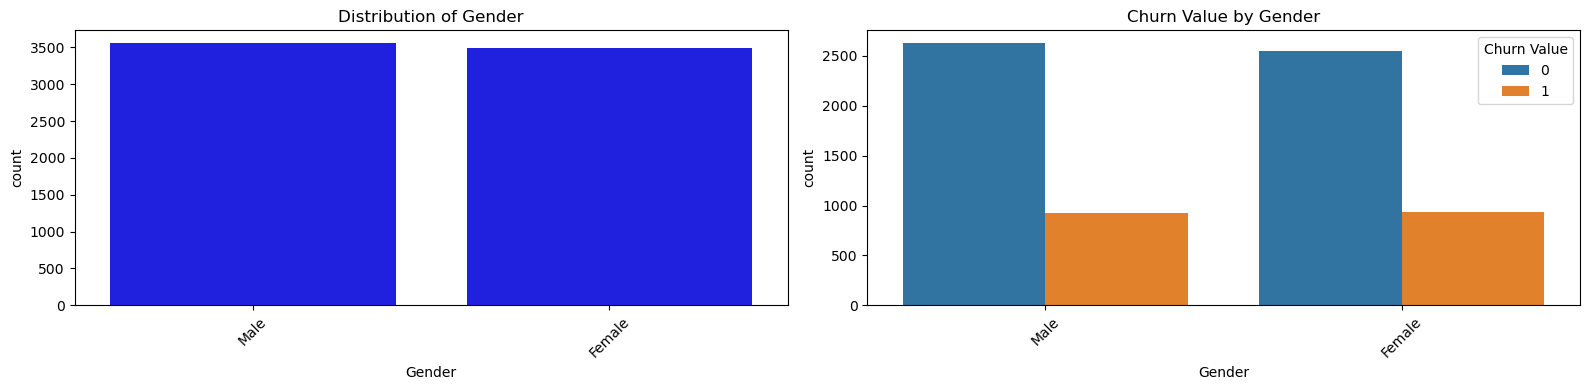

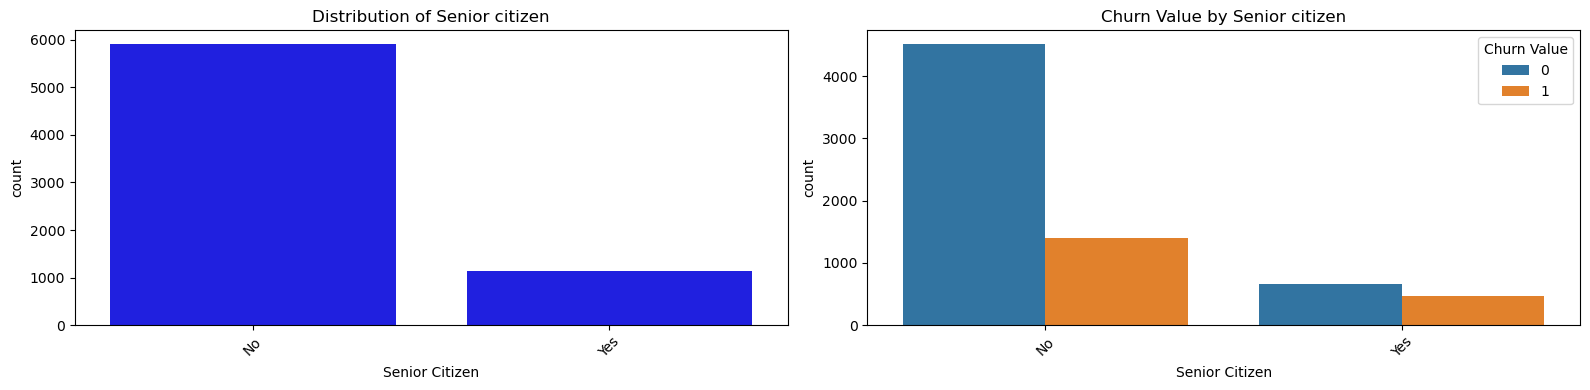

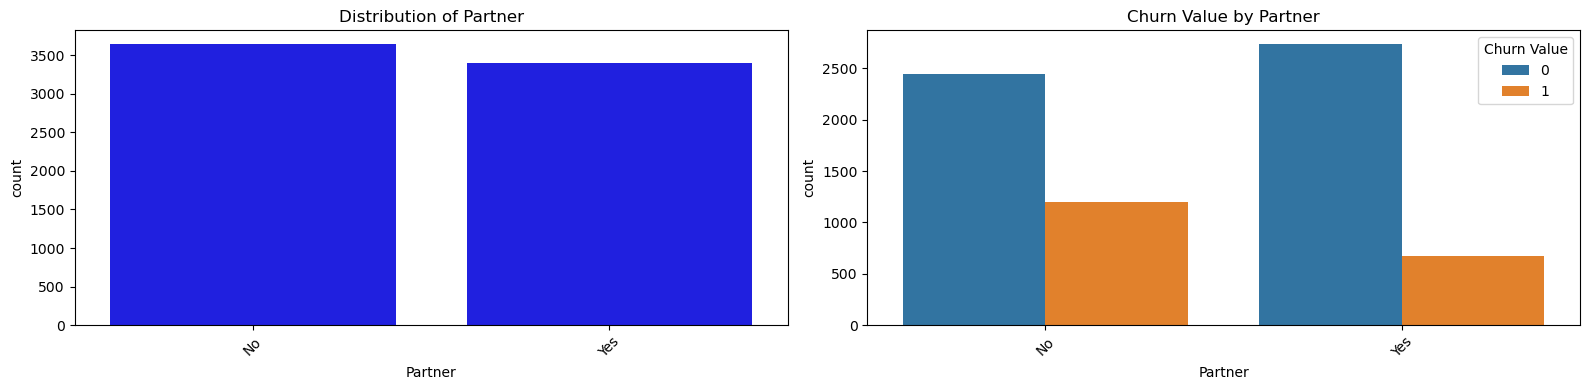

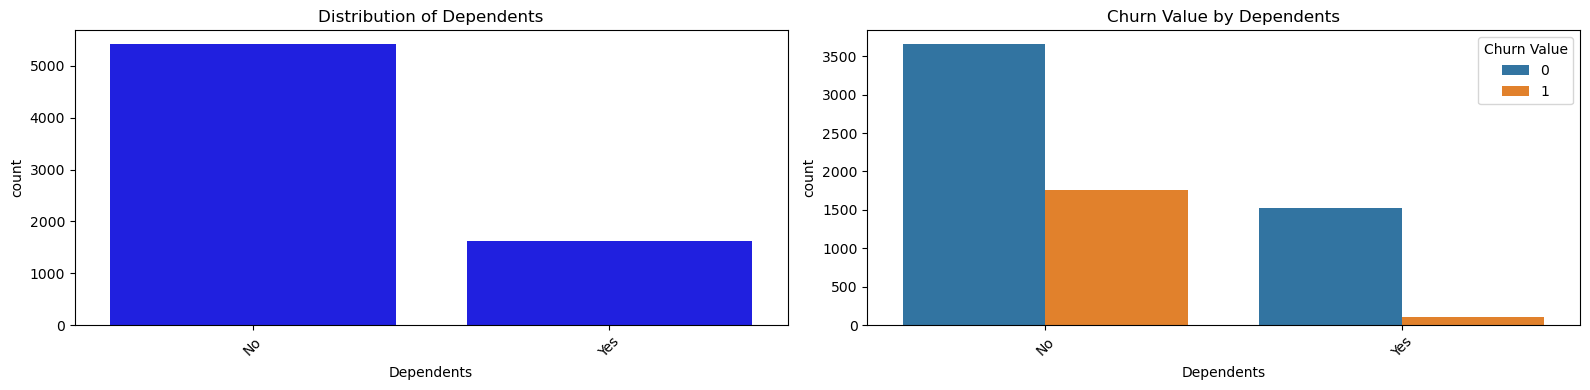

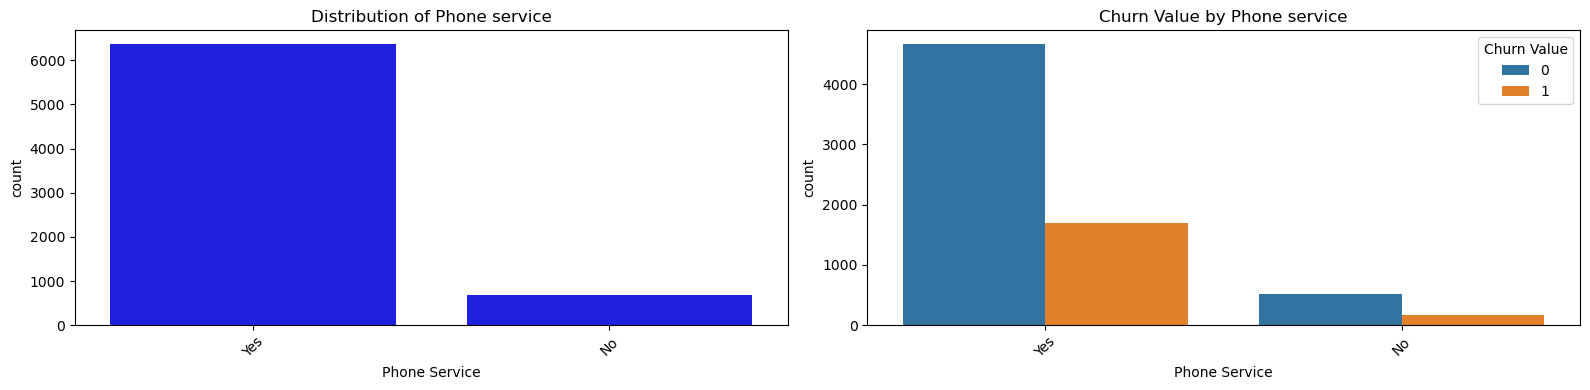

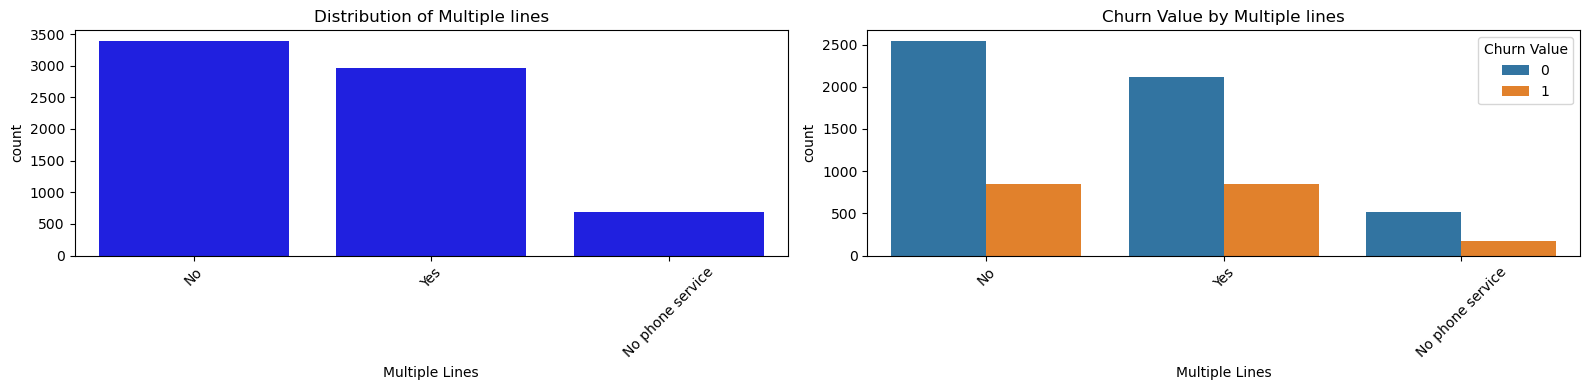

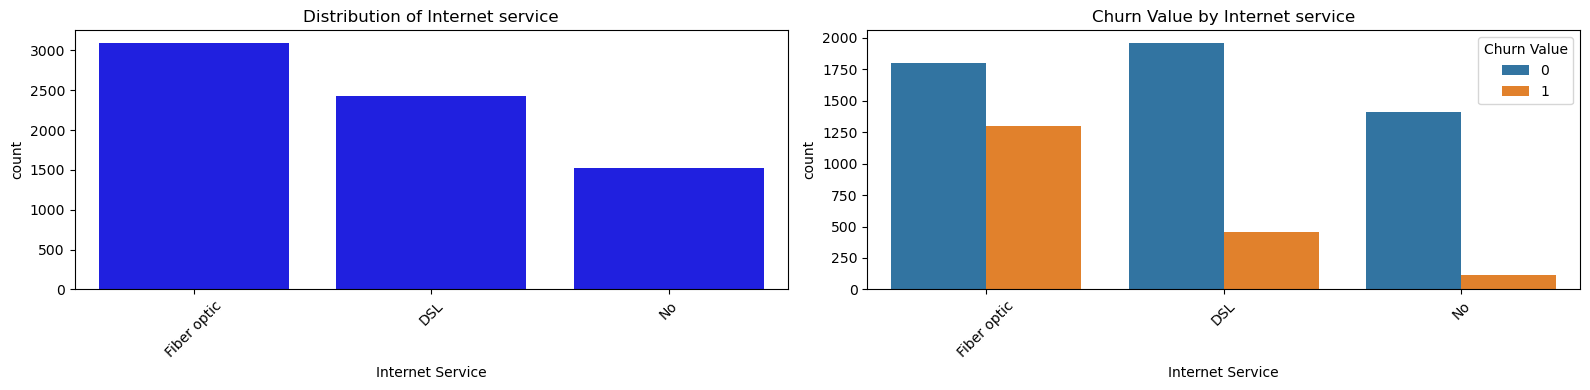

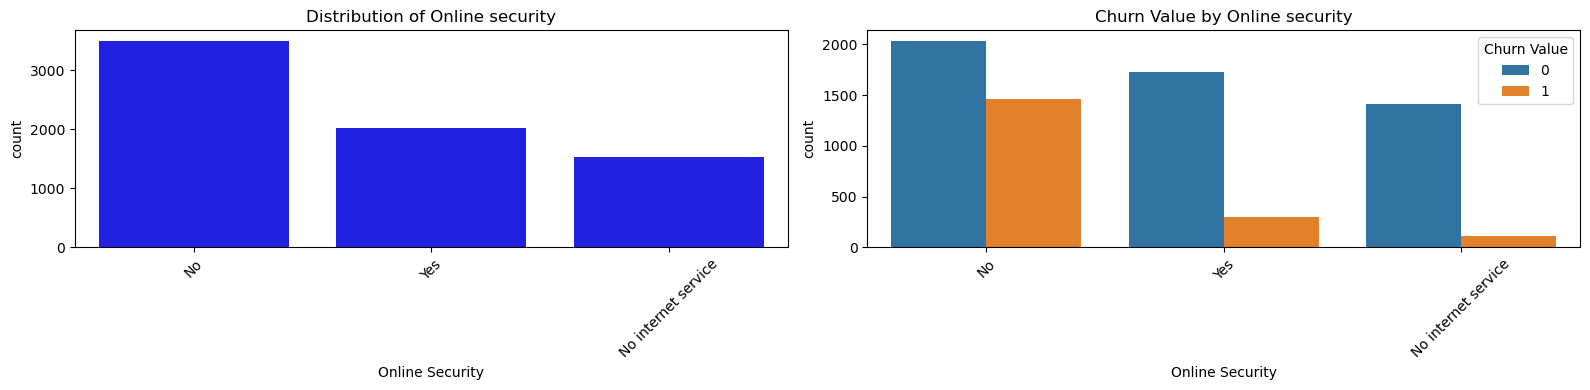

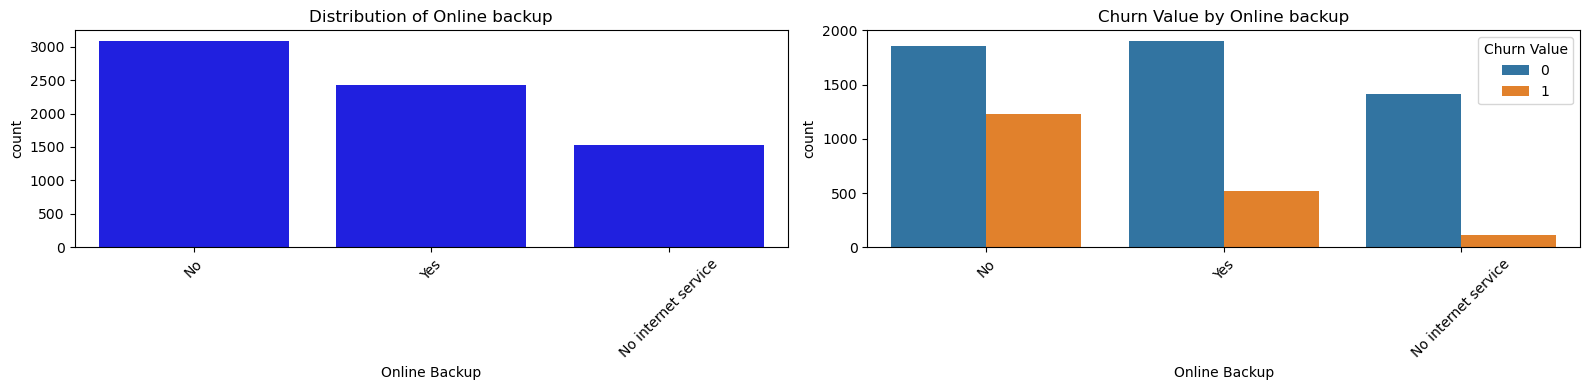

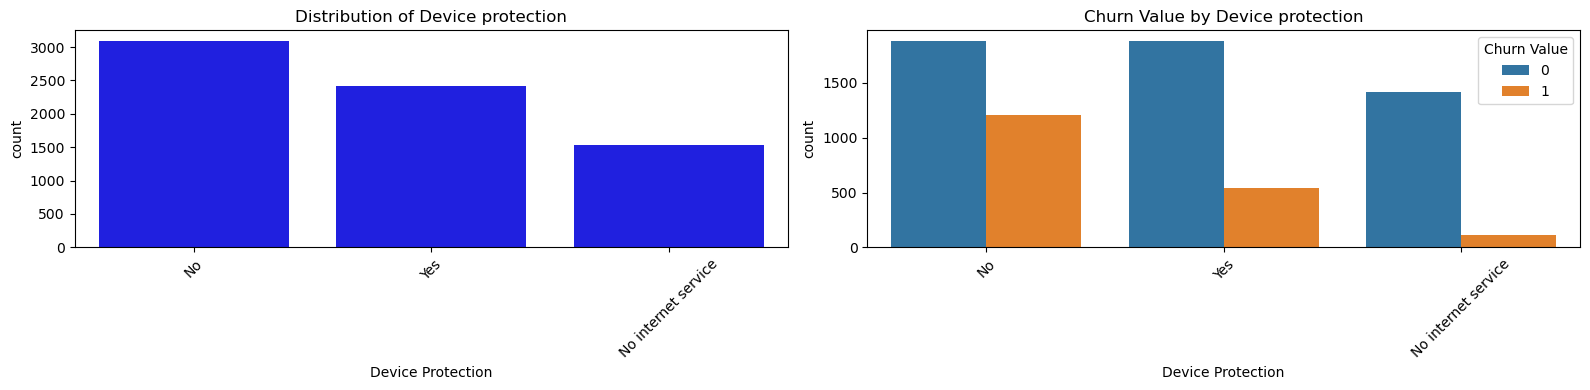

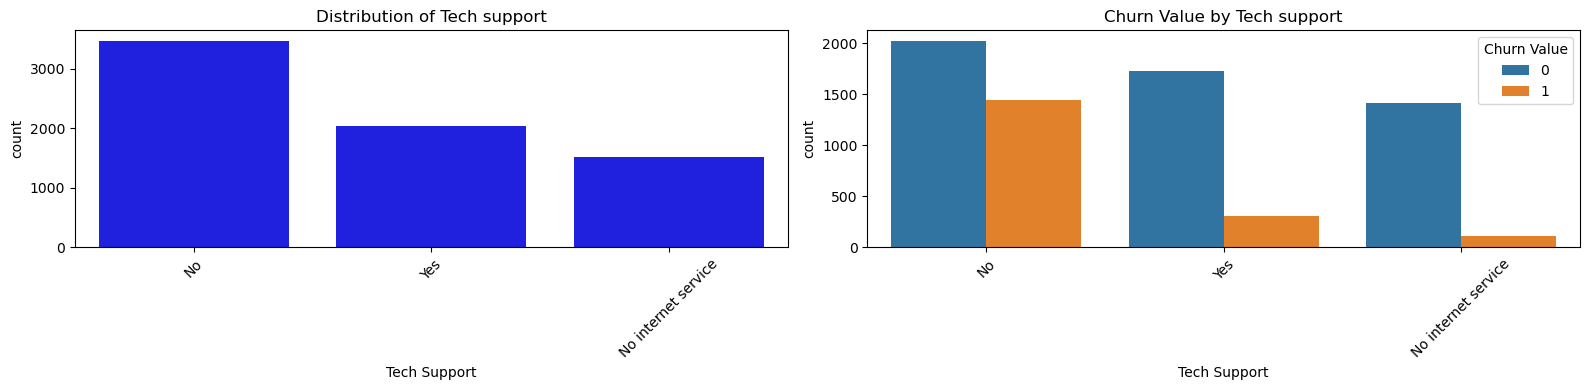

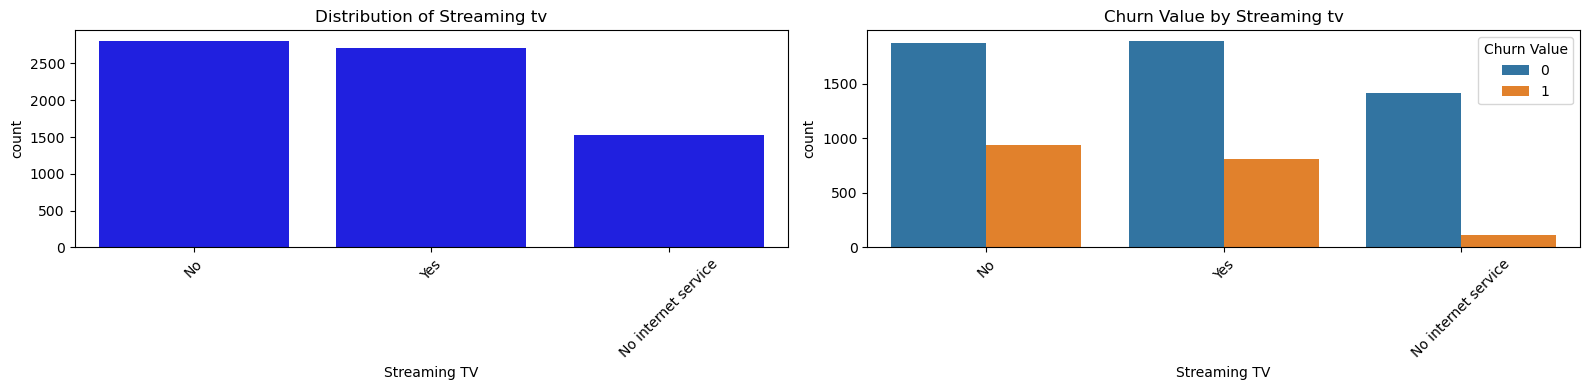

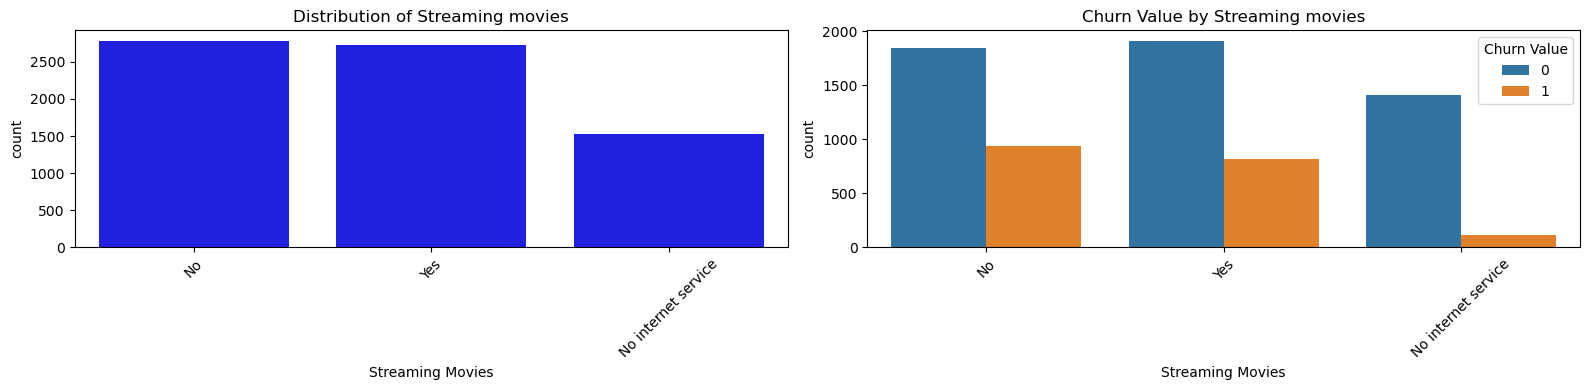

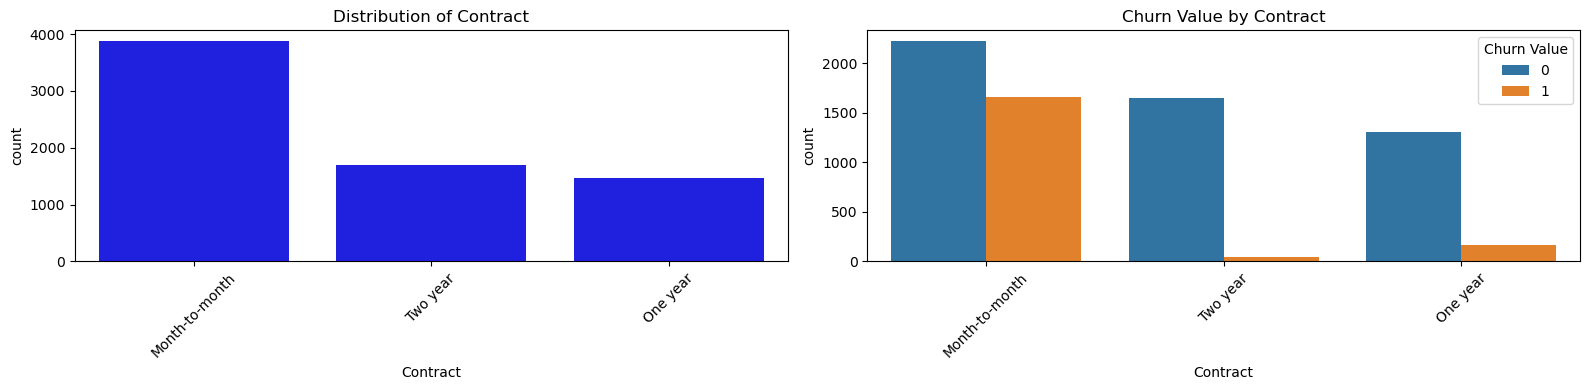

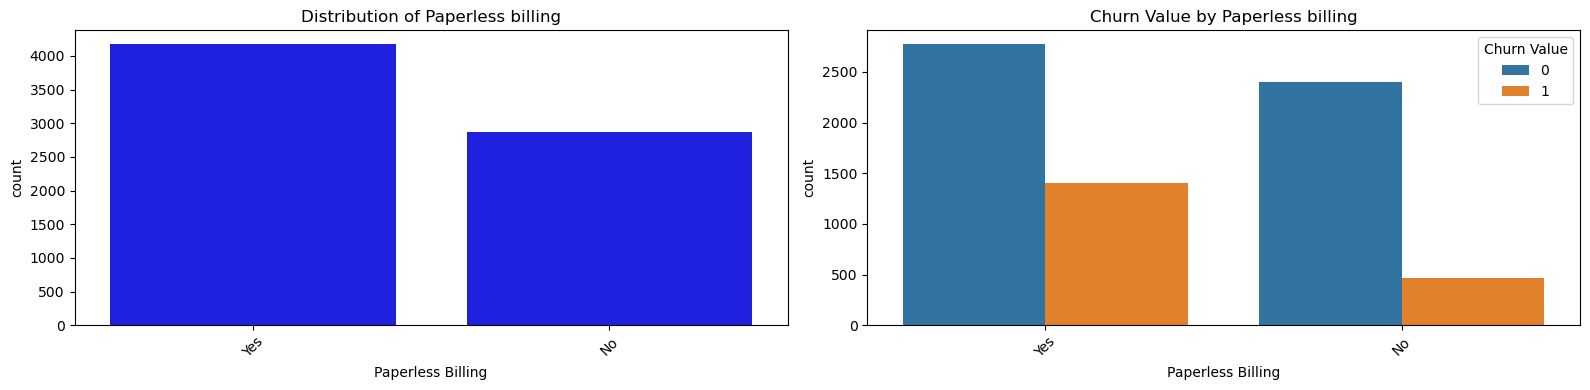

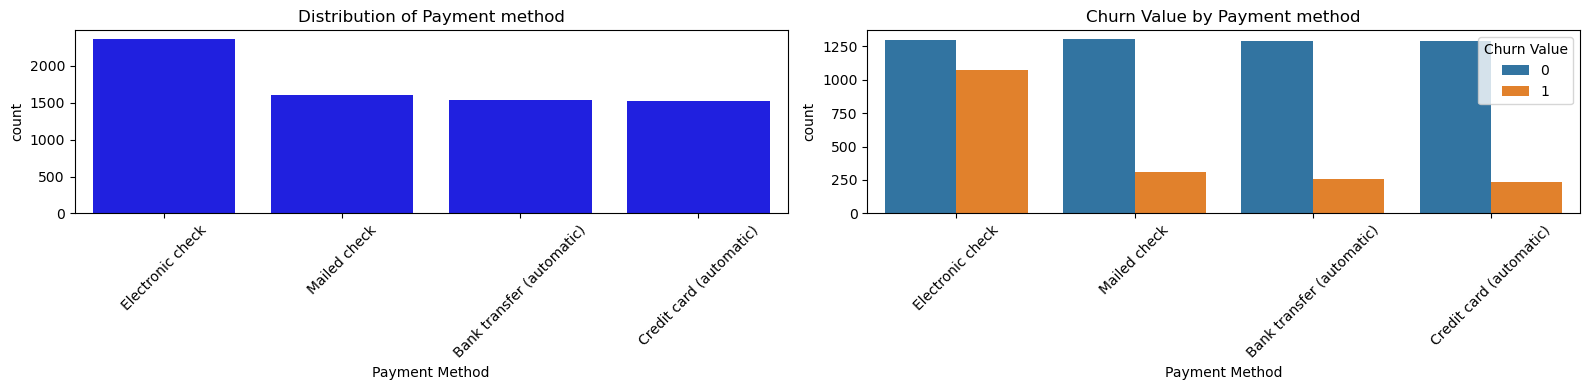

In [9]:
# Create 2 plots per categorical column (distribution + relationship with target)
for col in cat_col:
    if col == 'City':
        pass
    else:
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))
        
        category_order = df[col].value_counts().index
        
        # Left plot: Distribution
        sns.countplot(x=col, data=df, order=category_order, color='b', ax=axes[0])
        axes[0].set_title(f'Distribution of {col.capitalize()}')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Right plot: Relationship with target
        sns.countplot(data=df, x=col, hue='Churn Value', order=category_order, ax=axes[1])
        axes[1].set_title(f'Churn Value by {col.capitalize()}')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

# Model Development
## Problem Type:
This is a binary classification problem. I am predicting whether a customer will churn (1) or not (0) based on available features.

## Preprocessing Strategy:
- **Train-validation-test** split (**60/20/20**) with **stratification** to maintain class distribution
- *Numerical features*:
    - **SimpleImputer** +
    - **PowerTransformer** with yeo-johnson method +
    - **StandardScaler** normalization
- *Categorical features*:
    - **One-hot encoding** 
- *Hyperparameter tuning*:
    - **Bayesian** hyperparameter search

In [10]:
# Helper function for train-val-test split
from sklearn.model_selection import train_test_split

def train_val_test_split(X, y, test_size=0.2, val_size=0.25, random_state=None):
    """
    Split data into train, validation, and test sets with stratification.
    
    Parameters:
    -----------
    X : features
    y : target
    test_size : proportion of test set (default 0.2)
    val_size : proportion of validation set from train set (default 0.25)
    random_state : random seed for reproducibility
    
    Returns:
    --------
    X_train, X_val, X_test, y_train, y_val, y_test
    """
    # First split: train+val vs test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y)
    
    # Second split: train vs val
    val_size_adjusted = val_size / (1 - test_size) 
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, 
        test_size=val_size_adjusted, 
        random_state=random_state, 
        stratify=y_train_val)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [11]:
# Create train-test sets and set up the Kfold and other required parameters
# Libs
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline

# set up parameters for all models
random_state_ = 123
which_scoring = 'accuracy'

# Separate the predictor and target variable
X = df[num_col + cat_col]
y = df['Churn Value']

# Split the data into train, val, and test
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X, y,
    test_size=.2,
    val_size=.2,
    random_state=random_state_
)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state_)

# Create a preprocessing pipeline
from sklearn.compose import ColumnTransformer

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)) 
])

# Combine all transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_col),
        ('cat', categorical_transformer, cat_col)
    ],
    remainder='drop' 
)

In [12]:
# Create xgboost model using the sklearn API
import xgboost as xgb
import optuna
from sklearn.base import clone
optuna.logging.set_verbosity(optuna.logging.WARNING)
    
# Set up the pipeline for the XGBoost model
pipe_xgboost = Pipeline([
    ('preprocessing', preprocessor),
    ('xgb', xgb.XGBClassifier(
        random_state=random_state_,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

# Pass X_val through the preprocess pipeline
X_val_transformed = preprocessor.fit(X_train, y_train).transform(X_val)
pipe_xgboost.fit(X_train, y_train,  xgb__eval_set=[(X_val_transformed, y_val)])


# Function for optimizer
def objective(trial):
    try: 
        xgb_params = {
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'n_estimators': trial.suggest_int('n_estimators', 50, 1000, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 100, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 100, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.1, 10.0),
            'early_stopping_rounds': trial.suggest_int('early_stopping_rounds', 10, 50),
        }
        
        # Validate parameter combinations
        if xgb_params['learning_rate'] < 0.01 and xgb_params['n_estimators'] < 500:
            raise optuna.TrialPruned()
        if xgb_params['gamma'] > 5 and xgb_params['max_depth'] < 3:
            raise optuna.TrialPruned()
            
        # Clone and set parameters
        pipe_fold = clone(pipe_xgboost)
        params = {f'xgb__{k}': v for k, v in xgb_params.items()}
        pipe_fold.set_params(**params) 
    
        # Fit with eval_set only
        pipe_fold.fit(
            X_train, y_train,
            xgb__eval_set=[(X_val_transformed, y_val)],
            xgb__verbose=False
        )
        
        # Evaluate
        if which_scoring == 'roc_auc':
            y_pred_proba = pipe_fold.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, y_pred_proba)
        elif which_scoring == 'accuracy':
            score = accuracy_score(y_val, pipe_fold.predict(X_val))
        elif which_scoring == 'f1':
            score = f1_score(y_val, pipe_fold.predict(X_val))
        else:
            score = pipe_fold.score(X_val, y_val)
            
        # If score is NaN or infinite
        if np.isnan(score) or np.isinf(score):
            raise optuna.TrialPruned()
        
        # Store additional metrics for analysis
        trial.set_user_attr(
            'n_estimators_used', 
            pipe_fold.named_steps['xgb'].best_iteration + 1 if hasattr(pipe_fold.named_steps['xgb'], 'best_iteration') else xgb_params['n_estimators'])
        
        # Report intermediate value for pruning
        trial.report(score, step=0)
        
        # Check if trial should be pruned
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        return score
        
    except optuna.TrialPruned:
        raise
        
    except (ValueError, RuntimeError, MemoryError) as e:
        print(f"{type(e).__name__}: {e}")
        raise optuna.TrialPruned()
        
    except Exception as e:
        print(f"Unexpected error ({type(e).__name__}): {e}")
        raise optuna.TrialPruned()


# Run optimizer with pruning
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=random_state_),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=5,
        interval_steps=1
    )
)

# Use optimize from optuna on the hyperparameter space
study.optimize(objective, n_trials=100, show_progress_bar=True)


# Get best parameters
best_params = study.best_params
print(f"\nBest CV score: {study.best_value:.3f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Convert best_params to pipeline format
best_params_pipe = {}

for k, v in best_params.items():
    best_params_pipe[f'xgb__{k}'] = v 

# Fit final model with best parameters
print("\nTraining final model with best parameters...")
pipe_xgboost.set_params(**best_params_pipe)
pipe_xgboost.fit(
    X_train, y_train,
    xgb__eval_set=[(X_val_transformed, y_val)],
    xgb__verbose=False
)

# Add attributes for compatibility
pipe_xgboost.best_params_ = best_params
pipe_xgboost.best_score_ = study.best_value
pipe_xgboost.study_ = study

print("\nOptimization complete!")
print(f"Final model trained with {pipe_xgboost.named_steps['xgb'].best_iteration + 1 if hasattr(pipe_xgboost.named_steps['xgb'], 'best_iteration') else best_params.get('n_estimators', 'N/A')} trees")

[0]	validation_0-logloss:0.49718
[1]	validation_0-logloss:0.45642
[2]	validation_0-logloss:0.43354
[3]	validation_0-logloss:0.41754
[4]	validation_0-logloss:0.40731
[5]	validation_0-logloss:0.40126
[6]	validation_0-logloss:0.39606
[7]	validation_0-logloss:0.39297
[8]	validation_0-logloss:0.39178
[9]	validation_0-logloss:0.39037
[10]	validation_0-logloss:0.39023
[11]	validation_0-logloss:0.39046


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[12]	validation_0-logloss:0.39158
[13]	validation_0-logloss:0.38932
[14]	validation_0-logloss:0.39009
[15]	validation_0-logloss:0.39105
[16]	validation_0-logloss:0.39281
[17]	validation_0-logloss:0.39276
[18]	validation_0-logloss:0.39195
[19]	validation_0-logloss:0.39300
[20]	validation_0-logloss:0.39367
[21]	validation_0-logloss:0.39365
[22]	validation_0-logloss:0.39413
[23]	validation_0-logloss:0.39487
[24]	validation_0-logloss:0.39576
[25]	validation_0-logloss:0.39613
[26]	validation_0-logloss:0.39741
[27]	validation_0-logloss:0.39751
[28]	validation_0-logloss:0.39733
[29]	validation_0-logloss:0.39750
[30]	validation_0-logloss:0.39778
[31]	validation_0-logloss:0.39748
[32]	validation_0-logloss:0.39817
[33]	validation_0-logloss:0.39742
[34]	validation_0-logloss:0.39976
[35]	validation_0-logloss:0.40090
[36]	validation_0-logloss:0.40198
[37]	validation_0-logloss:0.40427
[38]	validation_0-logloss:0.40462
[39]	validation_0-logloss:0.40607
[40]	validation_0-logloss:0.40670
[41]	validatio

  0%|          | 0/100 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning:


Best CV score: 0.821
Best parameters:
  max_depth: 3
  n_estimators: 600
  learning_rate: 0.043915354234724695
  subsample: 0.7880887405057219
  colsample_bytree: 0.7348245169793497
  gamma: 1.4482395783839077
  reg_alpha: 0.12611069029183122
  reg_lambda: 0.005502973294915624
  min_child_weight: 5
  max_delta_step: 7
  scale_pos_weight: 1.0740924289168474
  early_stopping_rounds: 18

Training final model with best parameters...

Optimization complete!
Final model trained with 235 trees


In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# Make predictions on test set
y_pred = pipe_xgboost.predict(X_test)
y_pred_proba = pipe_xgboost.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print("="*50)
print("TEST SET PERFORMANCE:")
print("="*50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")

TEST SET PERFORMANCE:
Accuracy:  0.8041
ROC-AUC:   0.8522
F1-Score:  0.6134
Precision: 0.6441
Recall:    0.5856


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [14]:
# 1. Check for data leakage
print("Checking for potential data leakage...")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Check if any features are too correlated with target
import numpy as np
correlations = []
for col in X_train.columns:
    if X_train[col].dtype in ['int64', 'float64']:
        corr = np.corrcoef(X_train[col], y_train)[0, 1]
        correlations.append((col, abs(corr)))

correlations.sort(key=lambda x: x[1], reverse=True)
print("\nTop 5 correlated features with target:")
for col, corr in correlations[:5]:
    print(f"  {col}: {corr:.4f}")

# 2. Check validation performance
print("\n" + "="*50)
print("VALIDATION SET PERFORMANCE (for comparison):")
print("="*50)
y_val_pred = pipe_xgboost.predict(X_val)
y_val_pred_proba = pipe_xgboost.predict_proba(X_val)[:, 1]

print(f"Val Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Val ROC-AUC:   {roc_auc_score(y_val, y_val_pred_proba):.4f}")
print(f"Test/Val diff: {test_accuracy - accuracy_score(y_val, y_val_pred):.4f}")



Checking for potential data leakage...
Train shape: (4225, 24), Test shape: (1409, 24)

Top 5 correlated features with target:
  Tenure Months: 0.3401
  Monthly Charges: 0.2027
  Zip Code: 0.0084
  Longitude: 0.0059
  Latitude: 0.0045

VALIDATION SET PERFORMANCE (for comparison):
Val Accuracy:  0.8211
Val ROC-AUC:   0.8736
Test/Val diff: -0.0170


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [15]:
# Get the actual feature names after all transformations
def get_feature_names_after_preprocessing(pipeline, original_features):
    """
    Extract feature names after preprocessing in a pipeline
    """
    preprocessor = pipeline.named_steps['preprocessing']
    
    if hasattr(preprocessor, 'get_feature_names_out'):
        # For ColumnTransformer with get_feature_names_out
        return preprocessor.get_feature_names_out()
    else:
        # Manual extraction
        feature_names = []
        
        # Get transformers from ColumnTransformer
        for name, transformer, columns in preprocessor.transformers_:
            if name == 'num':
                # Numerical features
                feature_names.extend([f'num__{col}' for col in columns])
            elif name == 'cat':
                # Categorical features (one-hot encoded)
                # Get categories from OneHotEncoder
                encoder = transformer.named_steps['onehot']
                if hasattr(encoder, 'get_feature_names_out'):
                    cat_features = encoder.get_feature_names_out(columns)
                    feature_names.extend([f'cat__{feat}' for feat in cat_features])
                else:
                    # Fallback
                    for col in columns:
                        unique_vals = pipeline.named_steps['preprocessing'].named_transformers_['cat'].named_steps['onehot'].categories_[list(columns).index(col)]
                        for val in unique_vals[1:]:  # Skip first due to drop='first'
                            feature_names.append(f'cat__{col}_{val}')
        
        return feature_names

# Get feature names
try:
    feature_names = get_feature_names_after_preprocessing(pipe_xgboost, X_train.columns)
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': pipe_xgboost.named_steps['xgb'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n" + "="*50)
    print("TOP 15 FEATURE IMPORTANCES (with interpretation):")
    print("="*50)
    
    for idx, row in importance_df.head(15).iterrows():
        # Clean up feature names for readability
        clean_name = row['feature'].replace('num__', '').replace('cat__', '')
        
        # Add interpretation
        interpretation = ""
        if 'Tenure' in clean_name or 'tenure' in clean_name.lower():
            interpretation = "← Lower tenure = higher churn risk"
        elif 'Contract' in clean_name or 'contract' in clean_name.lower():
            if 'Month_to_month' in clean_name:
                interpretation = "← Month-to-month contracts churn more"
            elif 'Two_year' in clean_name:
                interpretation = "← Two-year contracts churn less"
        elif 'Monthly' in clean_name or 'monthly' in clean_name.lower():
            interpretation = "← Higher monthly charges = higher churn"
        elif 'OnlineSecurity' in clean_name:
            if 'No' in clean_name:
                interpretation = "← No online security = higher churn"
        
        print(f"{clean_name:40} {row['importance']:.4f} {interpretation}")
        
except Exception as e:
    print(f"Error getting feature names: {e}")
    # Simple version
    importance_values = pipe_xgboost.named_steps['xgb'].feature_importances_
    print(f"\nFeature importances (top 10 of {len(importance_values)} features):")
    for i, imp in enumerate(sorted(importance_values, reverse=True)[:10]):
        print(f"  Feature {i}: {imp:.4f}")


TOP 15 FEATURE IMPORTANCES (with interpretation):
Internet Service_Fiber optic             0.1625 
Contract_Two year                        0.1230 
Online Security_No internet service      0.0978 
Contract_One year                        0.0905 
Payment Method_Electronic check          0.0749 
Dependents_Yes                           0.0629 
Internet Service_No                      0.0430 
Tenure Months                            0.0388 ← Lower tenure = higher churn risk
Online Security_Yes                      0.0246 
Tech Support_Yes                         0.0205 
Total Charges                            0.0195 
Streaming Movies_Yes                     0.0192 
Paperless Billing_Yes                    0.0165 
Phone Service_Yes                        0.0145 
Streaming TV_Yes                         0.0141 
